In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
df_train = pd.read_csv("comment-category-prediction-challenge/train.csv") 
df_test = pd.read_csv("comment-category-prediction-challenge/test.csv") 

df_test["is_train"] = 0
df_train["is_train"] = 1
sample = pd.read_csv("comment-category-prediction-challenge/Sample.csv") 

In [ ]:
df_train.head()

### Let's start with feature engi and EDA on both train and test data

In [ ]:
df = pd.concat([df_train, df_test], ignore_index=True) #merged it so we can perform essentail eda and fe on both datasets
df

In [ ]:
numerical_objs = df_train.select_dtypes(include=['int64', 'float64']).columns
len(numerical_objs)

In [ ]:
df.info()

In [ ]:
display(df['race'].unique())
display(df['religion'].unique())
display(df['gender'].unique())
display(df['disability'].unique())
display(df['created_date'].unique())

In [ ]:
df[~df['race'].isna()]

In [ ]:
df['created_date'] = pd.to_datetime(df['created_date'], yearfirst=True)

In [ ]:
# creating separate day, month, year
df['Day'] = pd.to_datetime(df['created_date'], yearfirst=True).dt.day.astype(int)
df['Month'] = pd.to_datetime(df['created_date'], yearfirst=True).dt.month.astype(int)
df['Year'] = pd.to_datetime(df['created_date'], yearfirst=True).dt.year.astype(int)
df

In [ ]:
df['weekday'] = pd.to_datetime(df['created_date'], yearfirst=True).dt.weekday.astype(int)

In [ ]:
df['weekend'] = df['weekday'].isin([5,6]).astype(int) #to fetch the weekends
df['created_hour'] = pd.to_datetime(df['created_date']).dt.hour

In [ ]:
df.post_id.unique()

df.info()

In [ ]:
pd.get_dummies(df['race'])

### Handling categorical features: 
race, religion, gender : categorical to numerical

In [ ]:
df.isna().sum()
# race, religion, gender : categorical to numerical
cols = ['race', 'religion', 'gender']
for i in cols:
    df[i+'_missing'] = df[i].isna().astype(int)
    df[i]= df[i].fillna("Missing").astype(str)


In [ ]:
#insigts from graphs, trans people are usually label 1
df['is_trans'] = (df['gender'] == 'transgender').astype(int) #hight signa, for 1

### Handling comments:

In [ ]:
# handing missing vals:
df[df['comment'].isna()]
df['comment'] = df['comment'].fillna('').astype(str)

In [ ]:
# df['comment']= df['comment'].str.join(" ")
# cleaning and removing noise: 
df['comment'] = df['comment'].str.replace(r'http\S+', '', regex=True)
df['comment'] = df['comment'].str.replace(r'\s+', ' ', regex=True)
df[:3]['comment']

In [ ]:
df['comment_len'] = df['comment'].str.len()
# df['comment'] = df['comment'].str.lower()
df['word_cnt'] = df['comment'].str.split().str.len()
# pd.set_option('display.max_colwidth', None)
# df['comment'].head()
df["avg_words"] =df["comment_len"] /(df["word_cnt"]+1)


In [ ]:
df_train['comment']

In [ ]:
#some text intensive features:
df['num_!'] = df['comment'].str.count('!')
df['num_ques'] = df['comment'].str.count(r'\?')

In [ ]:
pd.set_option('display.max_colwidth', None)
df['comment'].head(3)

### Handling Emojis and Imp columns

In [ ]:
# df.info()
df['emoji_counts'] = df['emoticon_1']+df['emoticon_2']+df['emoticon_3']

In [ ]:
s = "She might be a bright spot for a party keou on Oahu dominated by greedy criminals or ethically challenged individuals."
s.lower()

### Handling Votes and performing FE on them: Engagement signls

**Let's see what all can we do with it:**
1. Total votes (we can simply sum them)
2. ratio of upvotes to downvotes(get the ratio)

*These are strong internal signal that'd be useful for prediction*

In [ ]:
# df.info()
# df[['upvote', 'downvote']]
df['votes_ratio'] = df['upvote']/(df['upvote']+df['downvote']+ 1e-9) #learning: to avoid inf (0/0) add 1e-9 in denominator [it's basically adding a raelly tiny number 0.0000000001 to avoid 0/0 case]


In [ ]:
#  balancing the magnitude : popularity magnitude or negative feedback magnitude using logx
df['upvote_log1'] = np.log1p(df['upvote'])
df['downvote_log1'] = np.log1p(df['downvote'])


In [ ]:
#engagement scorea nd intensiryt
df['engagement_score'] = df['upvote'] - df['downvote']
df['emoticon_density'] = df['emoji_counts'] / (df['word_cnt'] + 1)

In [163]:
df.columns

Index(['created_date', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3',
       'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender',
       'disability', 'comment', 'label', 'is_train', 'Day', 'Month', 'Year',
       'weekday', 'weekend', 'created_hour', 'race_missing',
       'religion_missing', 'gender_missing', 'comment_len', 'word_cnt',
       'num_!', 'num_ques', 'emoji_counts', 'votes_ratio', 'upvote_log1',
       'downvote_log1', 'engagement_score', 'emoticon_density',
       'post_comments_count', 'if_1_log', 'if_2_log', 'if_interaction_log',
       'sentiment_vader'],
      dtype='str')

In [ ]:
# df['post_id'].unique()
# df.groupby('post_id').size().
post_counts = df[df['is_train']==1].groupby('post_id').size().rename('post_comments_count')
# rest not seen will just point to 0
df['post_comments_count'] = df['post_id'].map(post_counts).fillna(0).astype(int)

In [ ]:
df[:5]

In [ ]:
# df.drop(['created_date'], axis = 1, inplace=True)
# df.dtypes
df.duplicated(subset=['created_date', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3',
       'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender',
       'disability', 'label', 'is_train', 'Day', 'Month', 'Year',
       'weekday', 'race_missing', 'religion_missing', 'gender_missing',
       'comment_len', 'word_cnt', 'emoji_counts', 'votes_ratio', 'upvote_log1',
       'downvote_log1']).sum() # the comment col is list, to avoid typeerror 

In [ ]:
# missing flags 
display(df.describe().T)
display(df.info())

In [ ]:
# outliers 
def iqr(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr  = q3 - q1
    lower, upper = q1-1.5*iqr, q3+1.5*iqr 
    return lower, upper, (s<lower).sum(), (s>upper).sum()

print("the Extreme valeus are :")
for i in ['upvote', 'downvote', 'if_1', 'if_2']:
    l,u,below,above = iqr(df[i])
    print(f"{i}: lower={l:.2f}, upper={u:.2f}, below={below}, above={above}")

# df['upvote'].quantile(0.75)

### Splitting before Encoding and all

In [ ]:
df['disability'] = df['disability'].astype(int) #0 is False and 1 is True
df.columns

In [ ]:
df.head().T

In [ ]:
display(df['race'].unique(),
df['religion'].unique(),
df['gender'].unique(),
df['post_id'].unique())

---
### Improvising : EDA and FE's (0.80 max from before) 

In [ ]:
# i'd somehow ignored the if_1 and 2 so let's resolve it - it'll give some boost to f1_score

df["if_1_log"] = np.log1p(df["if_1"]) #there are outliers
df["if_2_log"] = np.log1p(df["if_2"])

df["if_interaction_log"] = df["if_1_log"] * df["if_2_log"]

In [133]:
import nltk 
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from tqdm.auto import tqdm 

sia = SentimentIntensityAnalyzer()
comments_list = df['comment'].astype(str).tolist()

In [152]:
example = "Wow, I sence hostility and racism towards the \"white man\" in your last two posts Why are you using the (\"white man's) tools ??? Can't you just admire a persons accomplishment?? I have an idea since your disgusted by his using a man made object. Use natural items found in the Forrest to create your own non \"white man made\" products of any sort and do what he did. That would impress me. And no camera or video allowed, as that's not natural"
sia.polarity_scores(example)

{'neg': 0.168, 'neu': 0.693, 'pos': 0.139, 'compound': -0.6012}

In [134]:
sentiment_scores = [sia.polarity_scores(text)['compound'] for text in tqdm(comments_list)]
# sentiment = pd.DataFrame(sentiment_scores)
# sentiment = sentiment.reset_index().rename(columns={0: 'sentiment_score'})
sentiment_scores

  0%|          | 0/300000 [00:00<?, ?it/s]

100%|██████████| 300000/300000 [01:09<00:00, 4293.26it/s]


[-0.2023,
 0.0258,
 -0.9626,
 0.0,
 0.5106,
 0.4019,
 0.0,
 0.0516,
 0.1531,
 0.0,
 -0.4019,
 0.1027,
 -0.5048,
 -0.6369,
 0.4404,
 0.0,
 -0.2023,
 -0.6249,
 0.8933,
 -0.1531,
 0.7003,
 -0.4019,
 0.0,
 -0.7562,
 0.4019,
 0.0,
 0.9545,
 0.9061,
 -0.3875,
 0.4404,
 0.0,
 0.0,
 0.0,
 0.0,
 -0.8271,
 -0.7236,
 0.5423,
 0.0,
 0.5919,
 0.7374,
 -0.4939,
 -0.4741,
 -0.9428,
 0.7579,
 0.0,
 -0.9886,
 0.0,
 0.5913,
 -0.3248,
 -0.1027,
 0.296,
 -0.4767,
 -0.34,
 -0.6105,
 -0.0772,
 0.795,
 0.7964,
 0.5106,
 -0.6046,
 -0.8113,
 0.4939,
 -0.8807,
 0.0,
 0.4728,
 0.0,
 0.6752,
 0.5719,
 0.8172,
 0.94,
 0.9742,
 -0.8519,
 -0.9804,
 -0.5994,
 -0.6597,
 0.4137,
 0.8067,
 -0.34,
 -0.281,
 -0.7506,
 -0.734,
 0.2598,
 0.8087,
 0.6157,
 -0.7131,
 -0.1162,
 0.0,
 -0.2263,
 0.7579,
 0.128,
 0.6662,
 0.5423,
 0.9107,
 -0.4215,
 -0.6092,
 -0.9863,
 0.0,
 0.2635,
 0.5543,
 -0.9118,
 -0.5267,
 -0.1759,
 0.6068,
 -0.8562,
 -0.6486,
 -0.4084,
 0.3382,
 -0.2057,
 -0.2406,
 -0.1759,
 -0.8264,
 0.0,
 0.3612,
 -0.765

In [135]:
df['sentiment_vader'] = sentiment_scores
print("Done..")

Done..


<Axes: xlabel='label', ylabel='sentiment_vader'>

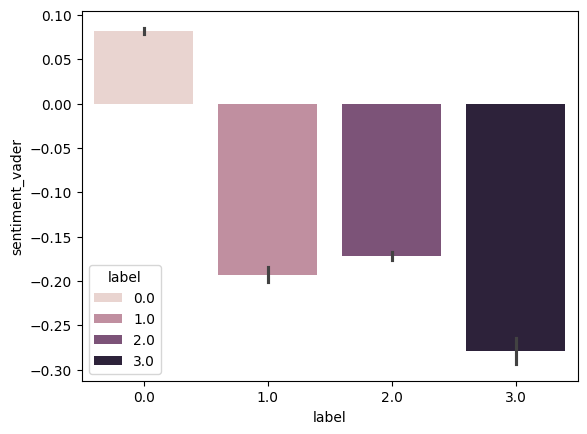

In [139]:
sns.barplot(data = df, x = 'label', y = 'sentiment_vader', hue='label')

In [175]:
from empath import Empath
lexicon  = Empath()
print("starting.. ")
comments_list = df['comment'][:50000].astype(str).tolist()
empath_res = [lexicon.analyze(text, normalize=True) or {} for text in tqdm(comments_list)]

starting.. 


100%|██████████| 50000/50000 [04:34<00:00, 182.14it/s]


In [173]:
empath_df = pd.DataFrame(empath_res).fillna(0.0)
empath_df = empath_df.add_prefix('empath_')
empath_df

,empath_help,empath_office,empath_dance,empath_money,empath_wedding,empath_domestic_work,empath_sleep,empath_medical_emergency,empath_cold,empath_hate,...,empath_weapon,empath_children,empath_monster,empath_ocean,empath_giving,empath_contentment,empath_writing,empath_rural,empath_positive_emotion,empath_musical
0,0.0,0.000000,0.0,0.000000,0.05,0.000000,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0000,0.000000
1,0.0,0.000000,0.0,0.009091,0.00,0.000000,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0000,0.000000
2,0.0,0.007519,0.0,0.000000,0.00,0.007519,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0000,0.000000
3,0.0,0.000000,0.0,0.000000,0.00,0.000000,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0000,0.000000
4,0.0,0.000000,0.0,0.000000,0.00,0.000000,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.025,0.0000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.0,0.000000,0.0,0.000000,0.00,0.000000,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0625,0.000000
996,0.0,0.000000,0.0,0.000000,0.00,0.000000,0.0,0.0,0.0,0.012048,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0000,0.012048
997,0.0,0.000000,0.0,0.000000,0.00,0.000000,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0000,0.000000
998,0.0,0.000000,0.0,0.000000,0.00,0.000000,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000,0.0000,0.000000


In [176]:
new_df = df[:50000].copy(deep = True)
new_fl = new_df.merge(empath_df, how='left')
new_fl.head()

MergeError: No common columns to perform merge on. Merge options: left_on=None, right_on=None, left_index=False, right_index=False

In [ ]:
empath_df.columns.to_list()

In [165]:
df.iloc[996]

created_date                                                                                                                                                                                                                                                                                                                                                                                                                                     2023-03-13 14:05:50.998155+00:00
post_id                                                                                                                                                                                                                                                                                                                                                                                                                                                                        39
emoticon_1                                                          

---

In [166]:
final_df = df.copy(deep=True)

In [167]:
# removing redundent cols:
final_df.drop(['created_date', 'Day', 'Month', 'Year'], axis=1, inplace=True)
final_df.drop(['upvote','downvote'], axis=1, inplace=True) #a few more

In [ ]:
final_df.dtypes

In [170]:
#Splitting the train and test
train_df = final_df[final_df['is_train'] == 1].copy(deep= True)
test_df = final_df[final_df['is_train'] == 0].copy(deep= True)

In [172]:
train_df.to_csv("train_df.csv")

In [ ]:
print(train_df.shape
, final_df.shape, df_train.shape) #just to verfiy the splitting wnet smoothly

print(test_df.shape
, final_df.shape, df_test.shape)

### After splitting train and test data: Real ML 

In [ ]:
train_df.columns

In [ ]:
x_ = train_df.drop(columns=['label','post_id'])
y_ = train_df['label'].astype(int).values
x_.shape, y_.shape

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    x_,
    y_,
    test_size=0.2,
    stratify=y_,
    random_state=42
)

In [ ]:
# X_train["post_mean"] = X_train["post_id"].map(post_stats["post_mean"])
# X_train["post_std"] = X_train["post_id"].map(post_stats["post_std"])
post_stats = X_train.assign(label= y_train).groupby("post_id")['label'].agg(post_mean = 'mean', post_std = "std")
# mapping the label mean found from train to val and test
post_stats.reset_index().set_index("post_id")

for data in [X_train, X_val, test_df]:
    data["post_mean"] = data["post_id"].map(post_stats["post_mean"])
    data["post_std"] = data["post_id"].map(post_stats["post_std"]).fillna(0.0)
# X_train[["post_id", 'post_mean',"post_std"]].groupby("post_id").value_counts()

## Encoding categorical features:

In [ ]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=True) #to avoid crash on unseen dataset

In [ ]:
categories = ['race', 'religion', 'gender']

X_train_ohe = ohe.fit_transform(X_train[categories])
X_val_ohe = ohe.transform(X_val[categories])
X_test_ohe = ohe.transform(test_df[categories])

In [ ]:
# encoded_df = pd.DataFrame(X_train_ohe.toarray(), columns= ohe.get_feature_names_out(['race', 'religion', 'gender']))
# display(encoded_df.head()) # the encoded data

### Using TF-IDF for comments


In [ ]:
train_df.shape

In [ ]:
# try#1:
# from sklearn.feature_extraction.text import TfidfVectorizer
# tfidf = TfidfVectorizer(max_features=20000, 
#                         ngram_range=(1,2), 
#                         min_df=5, 
#                         stop_words='english', 
#                         lowercase=True
# )

# X_train_text = tfidf.fit_transform(X_train['comment'])
# X_val_text = tfidf.transform(X_val['comment'])
# X_test_text = tfidf.transform(test_df['comment'])

In [ ]:
#try#2
#@title Tf-idf
from sklearn.feature_extraction.text import TfidfVectorizer

# word_tfidf = TfidfVectorizer(
#     max_features=15000,
#     ngram_range=(1,3),
#     min_df=3,
#     lowercase=True
# )

# char_tfidf = TfidfVectorizer(
#     max_features=5000,
#     analyzer='char',
#     ngram_range=(3,5)
# )

# X_train_word = word_tfidf.fit_transform(X_train['comment'])
# X_val_word   = word_tfidf.transform(X_val['comment'])
# X_test_word  = word_tfidf.transform(test_df['comment'])

# X_train_char = char_tfidf.fit_transform(X_train['comment'])
# X_val_char   = char_tfidf.transform(X_val['comment'])
# X_test_char  = char_tfidf.transform(test_df['comment'])

#have already saved!

In [ ]:
# #@title: trying senstece transformer instead of tf-idf to improve context
# from sentence_transformers import SentenceTransformer
# from sklearn.model_selection import RandomizedSearchCV
# from scipy.stats import loguniform

# import numpy as np

# model = SentenceTransformer("all-MiniLM-L6-v2")

# train_text_emb = model.encode(
#     X_train["comment"].tolist(),
#     batch_size=64,
#     show_progress_bar=True,
#     normalize_embeddings=True
# )

# val_text_emb = model.encode(
#     X_val["comment"].tolist(),
#     batch_size=64,
#     show_progress_bar=True,
#     normalize_embeddings=True
# )

# test_text_emb = model.encode(
#     test_df["comment"].tolist(),
#     batch_size=64,
#     show_progress_bar=True,
#     normalize_embeddings=True
# )

In [ ]:
from scipy.sparse import hstack, load_npz
# X_train_tfidf = hstack([X_train_word, X_train_char]).tocsr()
# X_val_tfidf   = hstack([X_val_word, X_val_char]).tocsr()
# X_test_tfidf  = hstack([X_test_word, X_test_char]).tocsr()
#have already saved

X_train_tfidf = load_npz('X_train_tfidf.npz')
X_val_tfidf   = load_npz('X_val_tfidf.npz')
X_test_tfidf  = load_npz('X_test_tfidf.npz')

# X_train_text = hstack([X_train_word, X_train_char])
# X_val_text   = hstack([X_val_word, X_val_char])
# X_test_text  = hstack([X_test_word, X_test_char])

#adding the embeddings 
train_text_emb = np.load('train_embeddings.npy')
val_text_emb = np.load('val_embeddings.npy')
test_text_emb = np.load('test_embeddings.npy')
# # join all the sparse matrices

from scipy.sparse import csr_matrix

X_train_emb_sparse = csr_matrix(train_text_emb)
X_val_emb_sparse   = csr_matrix(val_text_emb)
X_test_emb_sparse  = csr_matrix(test_text_emb)

In [ ]:
# from scipy.sparse import save_npz
# save_npz('X_train_tfidf',X_train_tfidf )
# save_npz('X_val_tfidf',X_val_tfidf )
# save_npz('X_test_tfidf',X_test_tfidf )
#can't waste time again and again

In [ ]:
# train_df.drop(['post_id'], axis=1, inplace=True) #will decide later
#mergin the ohe and main dataset
numerical_col = ['emoticon_1', 'emoticon_2', 'emoticon_3','if_1_log',
                'if_2_log','disability', 'weekend', 'created_hour','is_trans',
                'gender_missing', 'comment_len','avg_words',
                'num_!', 'num_ques', 'emoji_counts', 'votes_ratio', 'upvote_log1',
                'downvote_log1', 'engagement_score', 'emoticon_density',
                'post_comments_count', 'if_interaction_log',
                'sentiment_vader','if_interaction_sentiment', 'post_mean', 'post_std']  #excluded: ['post_id', 'comments', word_cnt,'race_missing', 'religion_missing', 'gender_missing', ]
 #excluded: ['post_id', 'comments', word_cnt,'race_missing', 'religion_missing', 'gender_missing', ]




In [ ]:
#scalling the numericals 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_num = scaler.fit_transform(X_train[numerical_col])
X_val_num   = scaler.transform(X_val[numerical_col])
X_test_num  = scaler.transform(test_df[numerical_col])

In [ ]:
#Merging everything 
# from scipy.sparse import hstack

# X_train_final = hstack([X_train_text, X_train_ohe, X_train_num])
# X_val_final   = hstack([X_val_text, X_val_ohe, X_val_num])
# X_test_final  = hstack([X_test_text, X_test_ohe, X_test_num])

In [ ]:
# x = X_train_final
# import copy 
# X_val_split, y_train_split, y_val_split = copy.deepcopy(X_val_final),copy.deepcopy(y_train),copy.deepcopy(y_val)

In [ ]:
# from scipy.sparse import save_npz  #use load_npz for the same
# save_npz('X_train_final.npz', X_train_final)
# save_npz('X_val_final.npz', X_val_final)
# save_npz('X_test_final.npz', X_test_final)

In [ ]:
# y_train.('y_train.csv', index  = False)
# y_val.to_csv('y_val.csv', index  = False)
# np.save('y_train', y_train)
# np.save('y_val', y_val)

### Merger for final Dataset

In [ ]:
# final dataset
X_train_final = hstack([
    X_train_tfidf,
    X_train_emb_sparse,
    X_train_ohe,
    X_train_num
])

X_val_final = hstack([
    X_val_tfidf,
    X_val_emb_sparse,
    X_val_ohe,
    X_val_num
])

X_test_final = hstack([
    X_test_tfidf,
    X_test_emb_sparse,
    X_test_ohe,
    X_test_num
])

In [ ]:
#merge#2
# X_train_final = np.hstack([train_text_emb, X_train_ohe, X_train_num])
# X_val_final   = np.hstack([val_text_emb, X_val_ohe, X_val_num])
# X_test_final   = np.hstack([test_text_emb, X_test_ohe, X_test_num])

In [ ]:
# from scipy.sparse import csr_matrix

# X_train_num = csr_matrix(train_df[numerical_col].values)
# X_test_num = csr_matrix(test_df[numerical_col].values)

In [ ]:
# #merge all
# from scipy.sparse import hstack

# X_train = hstack([X_train_num, X_train_ohe, X_train_text], format='csr')
# X_test = hstack([X_test_num, X_test_ohe, X_test_text], format='csr')


In [ ]:
# Am saving the manipulated dataset here so we can perform modelling in another notebook
# from scipy.sparse import save_npz  #use load_npz for the same
# save_npz('X_train_.npz', X_train)
# save_npz('X_test_.npz', X_test)

In [ ]:
# print(X_train.shape)
# print(X_test.shape)

In [ ]:
# train_df['label']

## visualisations and insigsts

In [ ]:
# will go the visaulising in another notebook
# final_df.to_csv('final_df.csv', index  = False)
# train_df.to_csv('train_df.csv', index  = False)

In [ ]:
# df.to_csv('df.csv', index  = False)

In [ ]:
import copy
X_train_split = copy.deepcopy(X_train_final)
X_val_split, y_train_split, y_val_split = copy.deepcopy(X_val_final),copy.deepcopy(y_train),copy.deepcopy(y_val)

### **Updation after analysising with visualisations:**


Alright after seeing the accuracy results 

### **Model training and testing**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score

lr = LogisticRegression(
    max_iter=1000,
    class_weight={
        0: 1,
        1: 1.2,
        2: 1,
        3: 3 
    },
    C=2.0,
    n_jobs=-1
)

lr = LogisticRegression()

In [ ]:
lr.fit(X_train_split, y_train_split)
y_pred = lr.predict(X_val_split)


In [ ]:
print(classification_report(y_val_split, y_pred))
print("f1_sctrore: ", f1_score(y_val_split, y_pred, average='macro'))

#output:
              precision    recall  f1-score   support

           0       0.95      0.94      0.95     22835
           1       0.75      0.75      0.75      3183
           2       0.87      0.88      0.87     12488
           3       0.61      0.68      0.64      1094

    accuracy                           0.90     39600
   macro avg       0.79      0.81      0.80     39600
weighted avg       0.90      0.90      0.90     39600

Macro F1: 0.8026683849892419